In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/eye-cancer-patient-records/eye_cancer_patients.csv


In [2]:
import pandas as pd 
import numpy as np 
from matplotlib import pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('/kaggle/input/eye-cancer-patient-records/eye_cancer_patients.csv')
df.head()

,Patient_ID,Age,Gender,Cancer_Type,Laterality,Date_of_Diagnosis,Stage_at_Diagnosis,Treatment_Type,Surgery_Status,Radiation_Therapy,Chemotherapy,Outcome_Status,Survival_Time_Months,Genetic_Markers,Family_History,Country
0,PID00001,58,F,Retinoblastoma,Left,2019-01-25,Stage IV,Radiation,False,15,3,Deceased,85,NaN,True,UK
1,PID00002,15,Other,Retinoblastoma,Right,2021-10-21,Stage III,Chemotherapy,True,69,6,In Remission,10,NaN,True,Japan
2,PID00003,64,M,Retinoblastoma,Bilateral,2021-03-12,Stage IV,Surgery,False,47,6,In Remission,3,BRAF Mutation,False,UK
3,PID00004,33,M,Melanoma,Right,2021-05-10,Stage II,Radiation,True,36,6,Active,40,NaN,False,Canada
4,PID00005,8,Other,Lymphoma,Left,2019-11-24,Stage I,Chemotherapy,False,14,14,In Remission,26,BRAF Mutation,True,USA


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Patient_ID            5000 non-null   object
 1   Age                   5000 non-null   int64 
 2   Gender                5000 non-null   object
 3   Cancer_Type           5000 non-null   object
 4   Laterality            5000 non-null   object
 5   Date_of_Diagnosis     5000 non-null   object
 6   Stage_at_Diagnosis    5000 non-null   object
 7   Treatment_Type        5000 non-null   object
 8   Surgery_Status        5000 non-null   bool  
 9   Radiation_Therapy     5000 non-null   int64 
 10  Chemotherapy          5000 non-null   int64 
 11  Outcome_Status        5000 non-null   object
 12  Survival_Time_Months  5000 non-null   int64 
 13  Genetic_Markers       2503 non-null   object
 14  Family_History        5000 non-null   bool  
 15  Country               5000 non-null   

In [5]:
df.isnull().sum()

Patient_ID                 0
Age                        0
Gender                     0
Cancer_Type                0
Laterality                 0
Date_of_Diagnosis          0
Stage_at_Diagnosis         0
Treatment_Type             0
Surgery_Status             0
Radiation_Therapy          0
Chemotherapy               0
Outcome_Status             0
Survival_Time_Months       0
Genetic_Markers         2497
Family_History             0
Country                    0
dtype: int64

In [6]:
df['Genetic_Markers'] = df['Genetic_Markers'].fillna('HAND')

<Axes: >

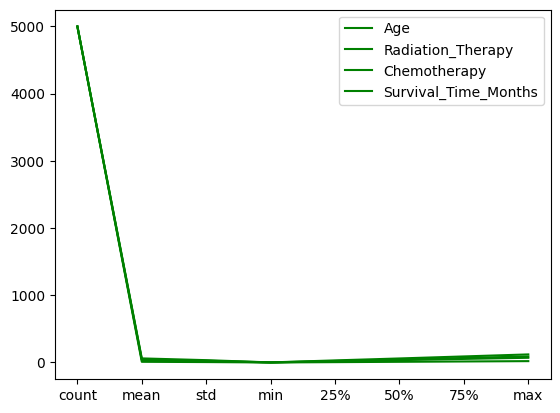

In [7]:
df.describe().plot(kind='line',color='g')

In [8]:
df = df.drop('Patient_ID',axis=1)

In [9]:
df.dtypes

Age                      int64
Gender                  object
Cancer_Type             object
Laterality              object
Date_of_Diagnosis       object
Stage_at_Diagnosis      object
Treatment_Type          object
Surgery_Status            bool
Radiation_Therapy        int64
Chemotherapy             int64
Outcome_Status          object
Survival_Time_Months     int64
Genetic_Markers         object
Family_History            bool
Country                 object
dtype: object

In [10]:
df.shape

(5000, 15)

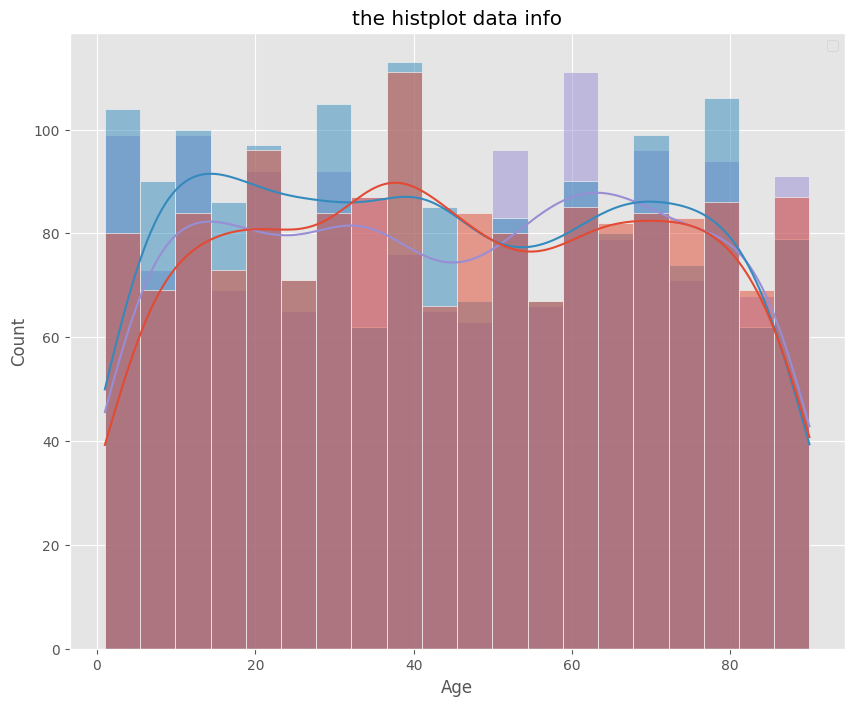

In [11]:
plt.figure(figsize=(10,8))
plt.style.use('ggplot')
sns.histplot(x='Age',data=df,kde=True,bins=20,hue='Gender')
plt.title('the histplot data info')
plt.grid(True)
plt.legend()
plt.show()

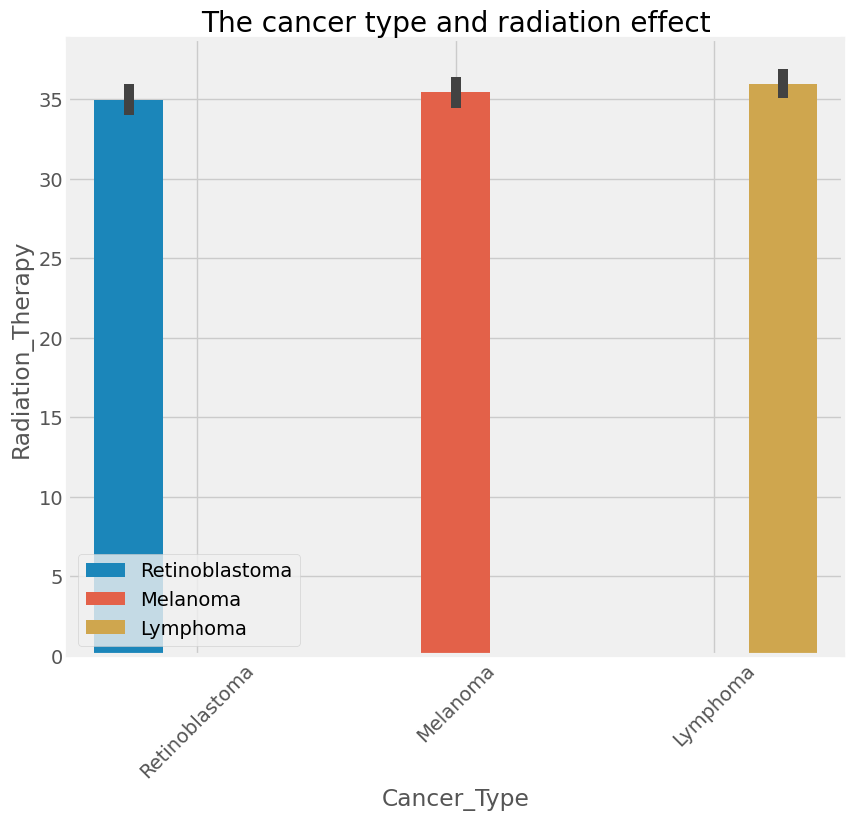

In [12]:
plt.figure(figsize=(10,8))
plt.style.use('fivethirtyeight')
sns.barplot(x='Cancer_Type',y='Radiation_Therapy',data=df,hue='Cancer_Type')
plt.title('The cancer type and radiation effect')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

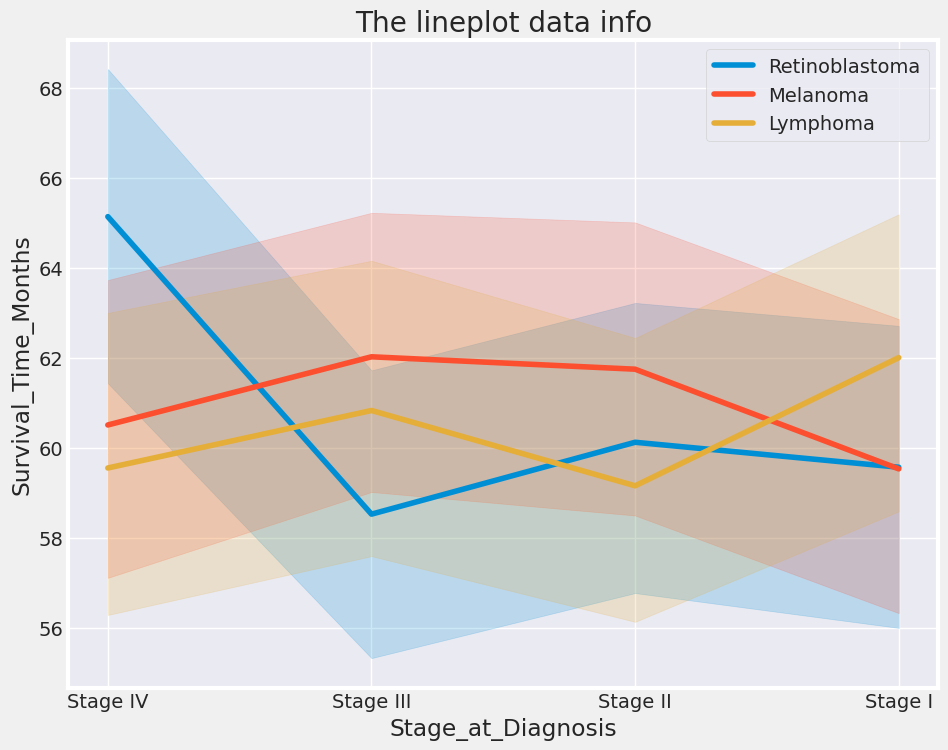

In [13]:
plt.figure(figsize=(10,8))
sns.set_style('darkgrid')
sns.lineplot(x='Stage_at_Diagnosis',y='Survival_Time_Months',data=df,markers='*',hue='Cancer_Type',color='teal')
plt.title('The lineplot data info')
plt.legend()
plt.grid(True)
plt.show()

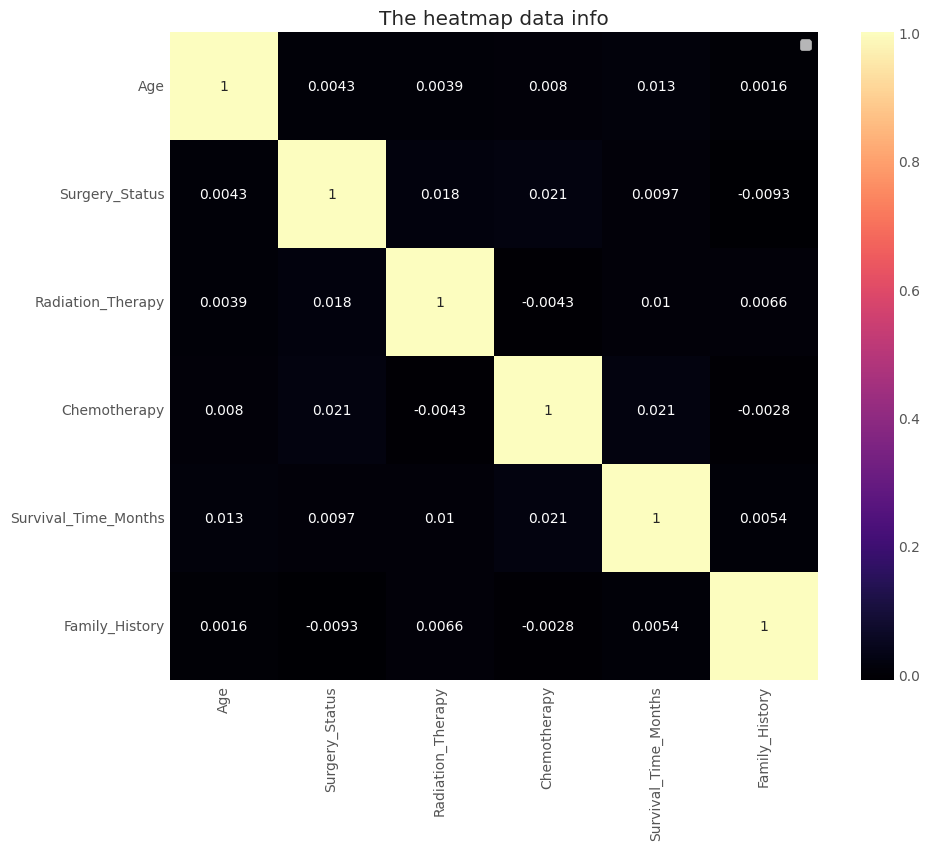

In [14]:
plt.figure(figsize=(10,8))
plt.style.use('ggplot')
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='magma',square=True,color='g')
plt.title('The heatmap data info')
plt.legend()
plt.show()

In [15]:
df['Date_of_Diagnosis'] = pd.to_datetime(df['Date_of_Diagnosis'])
df['month'] = df['Date_of_Diagnosis'].dt.strftime('%B')
df['month'].value_counts()

month
October      465
December     444
June         434
November     427
March        426
January      409
May          406
August       406
September    404
April        400
July         395
February     384
Name: count, dtype: int64

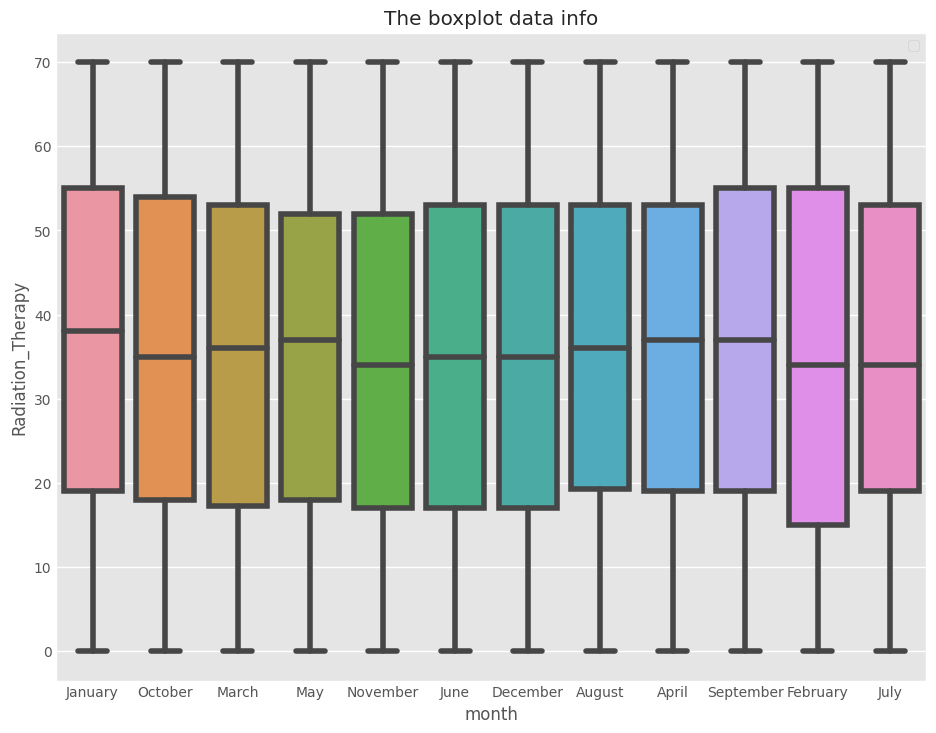

In [16]:
plt.figure(figsize=(10,8))
sns.boxplot(y='Radiation_Therapy',x='month',data=df)
plt.title('The boxplot data info')
plt.legend()
plt.show()

In [17]:
df.columns

Index(['Age', 'Gender', 'Cancer_Type', 'Laterality', 'Date_of_Diagnosis',
       'Stage_at_Diagnosis', 'Treatment_Type', 'Surgery_Status',
       'Radiation_Therapy', 'Chemotherapy', 'Outcome_Status',
       'Survival_Time_Months', 'Genetic_Markers', 'Family_History', 'Country',
       'month'],
      dtype='object')

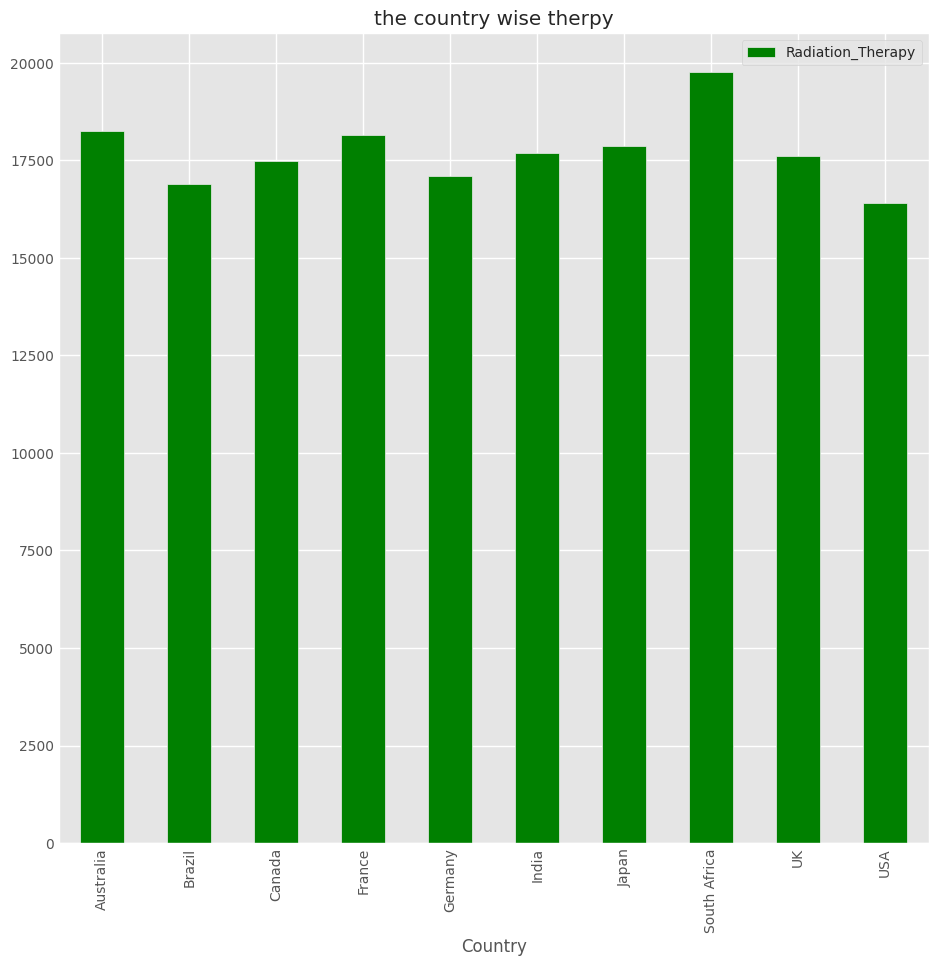

In [18]:
country_therpy = df.groupby('Country')['Radiation_Therapy'].sum()

plt.figure(figsize=(10,10))
country_therpy.plot(kind='bar',color='g')
plt.title('the country wise therpy')
plt.legend()
plt.show()

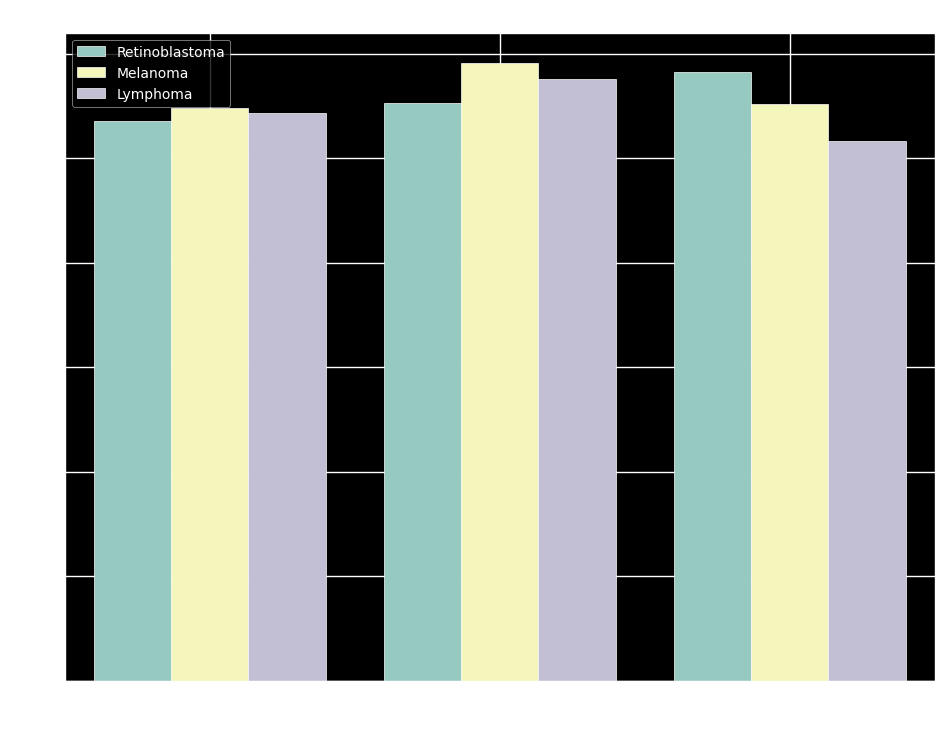

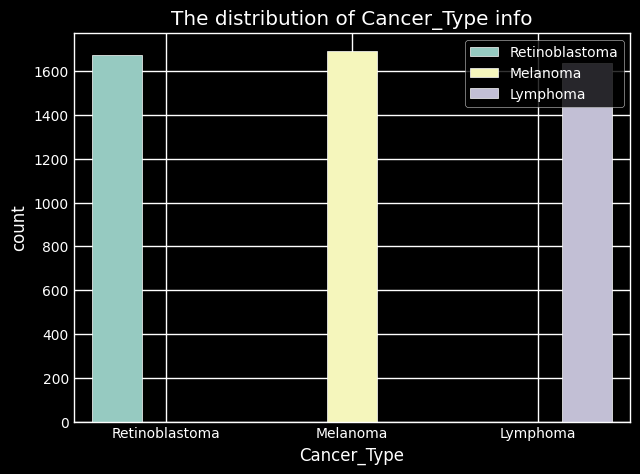

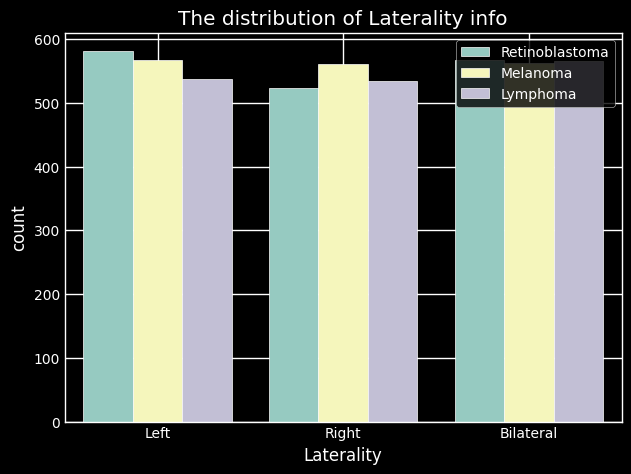

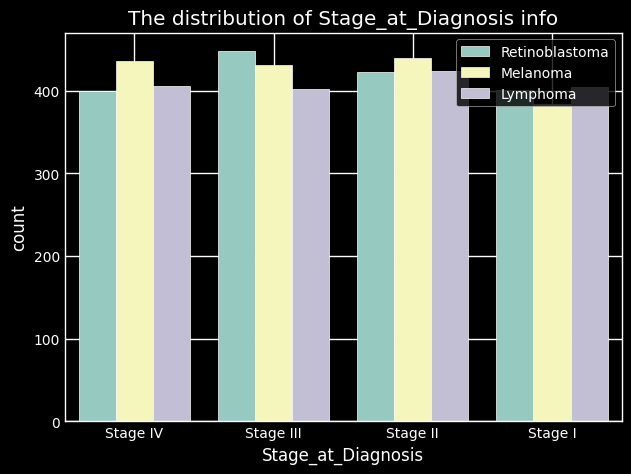

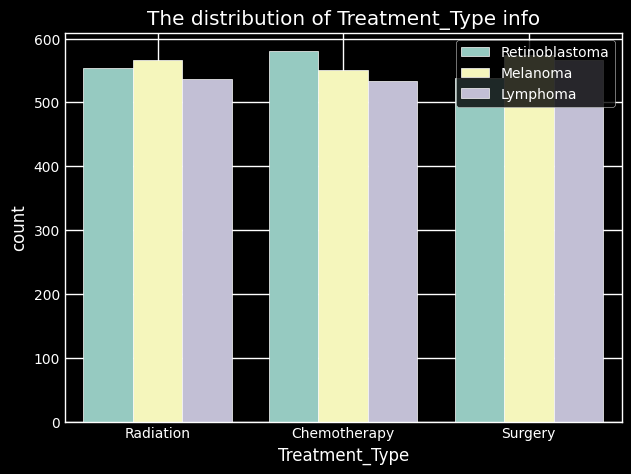

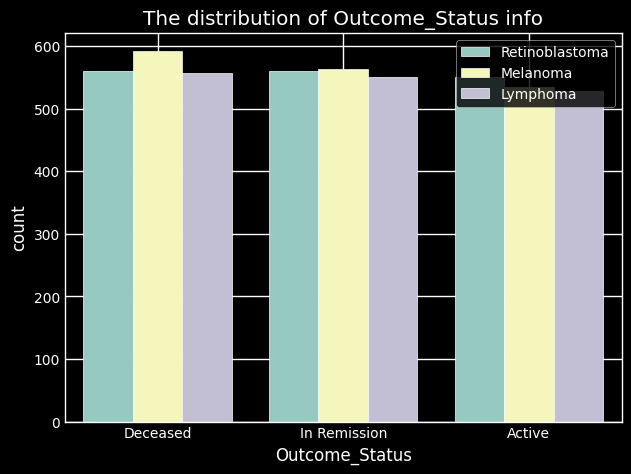

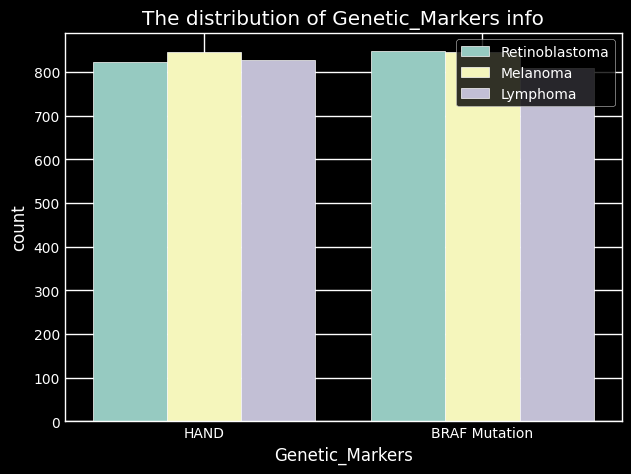

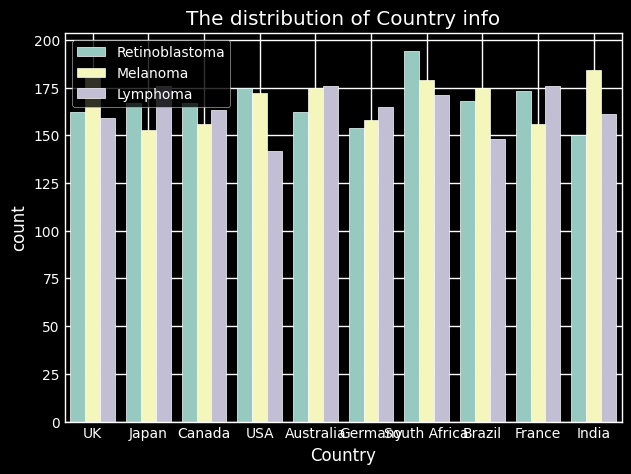

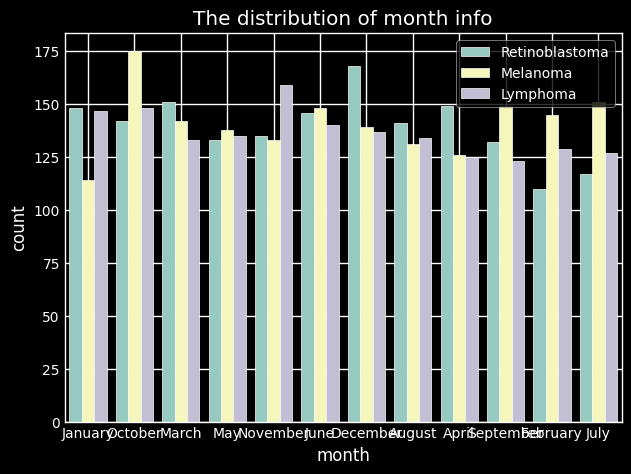

In [19]:
category_col = df.select_dtypes(include='object').columns 

plt.figure(figsize=(10,8))
plt.style.use('dark_background')
for col in category_col:
    sns.countplot(x=col,data=df,hue='Cancer_Type')
    plt.title(f'The distribution of {col} info')
    plt.legend()
    plt.grid(True)
    plt.show()

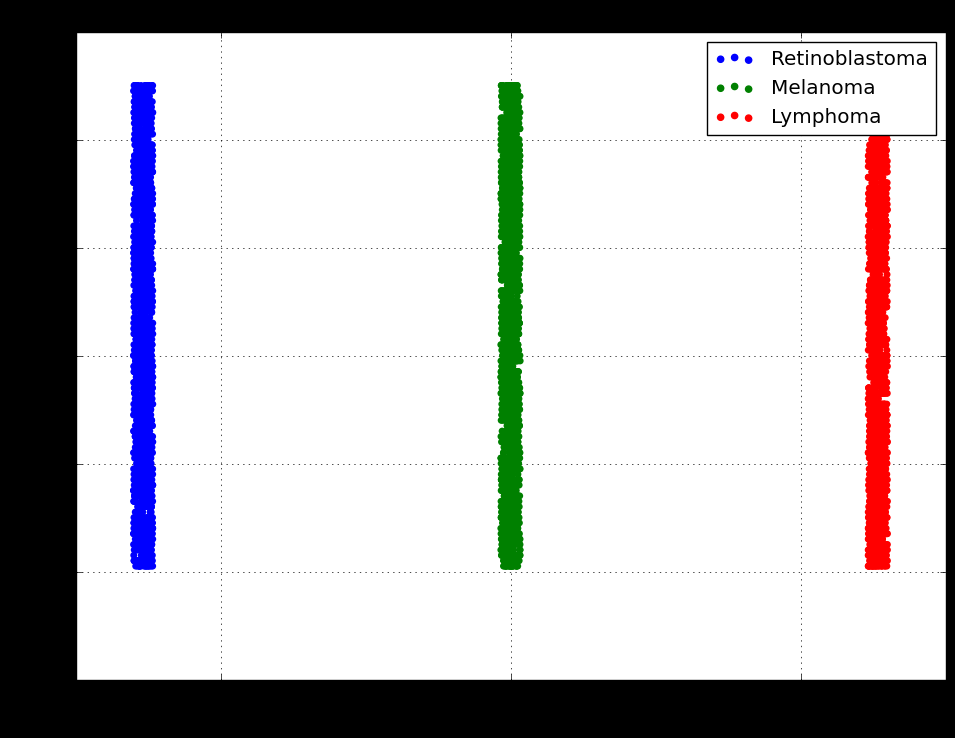

In [20]:
plt.figure(figsize=(10,8))
plt.style.use('classic')
sns.stripplot(x='Cancer_Type', y='Age', data=df, hue='Cancer_Type', dodge=True)
plt.title('the stripplot data info')
plt.legend()
plt.grid(True)
plt.show()

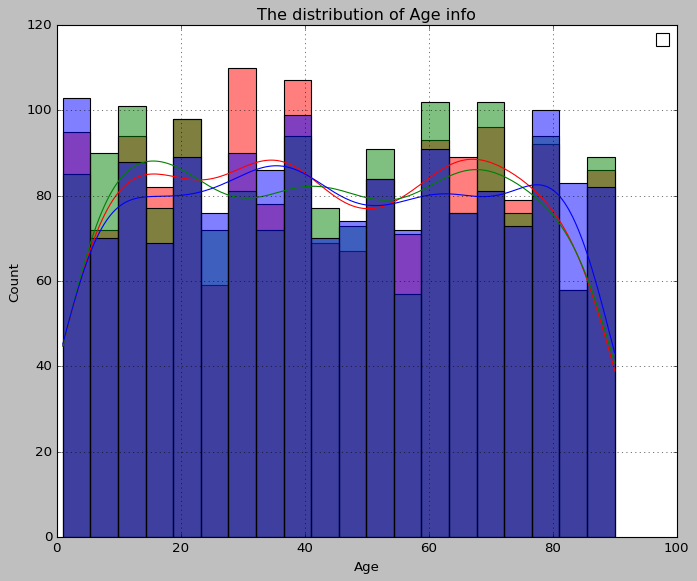

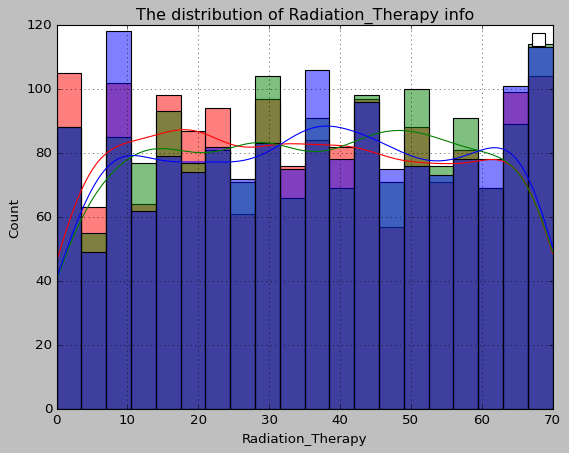

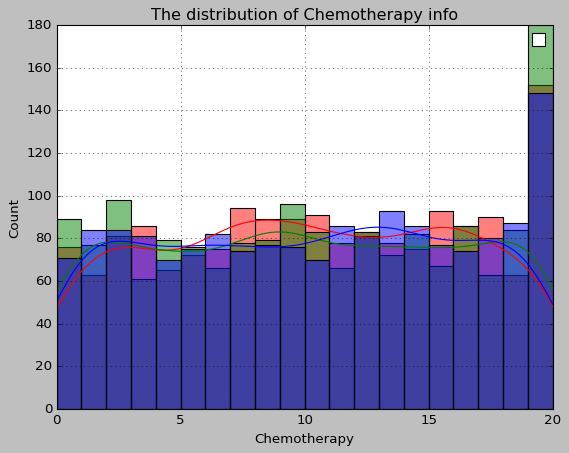

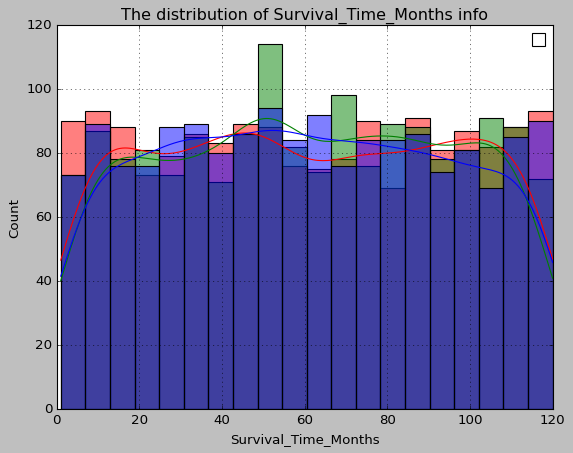

In [21]:
numerical_col = df.select_dtypes(include=np.number).columns 

plt.figure(figsize=(10,8))
for col in numerical_col:
    sns.histplot(x=col,data=df,kde=True,bins=20,hue='Treatment_Type')
    plt.title(f'The distribution of {col} info')
    plt.legend()
    plt.grid(True)
    plt.show()

<Figure size 800x800 with 0 Axes>

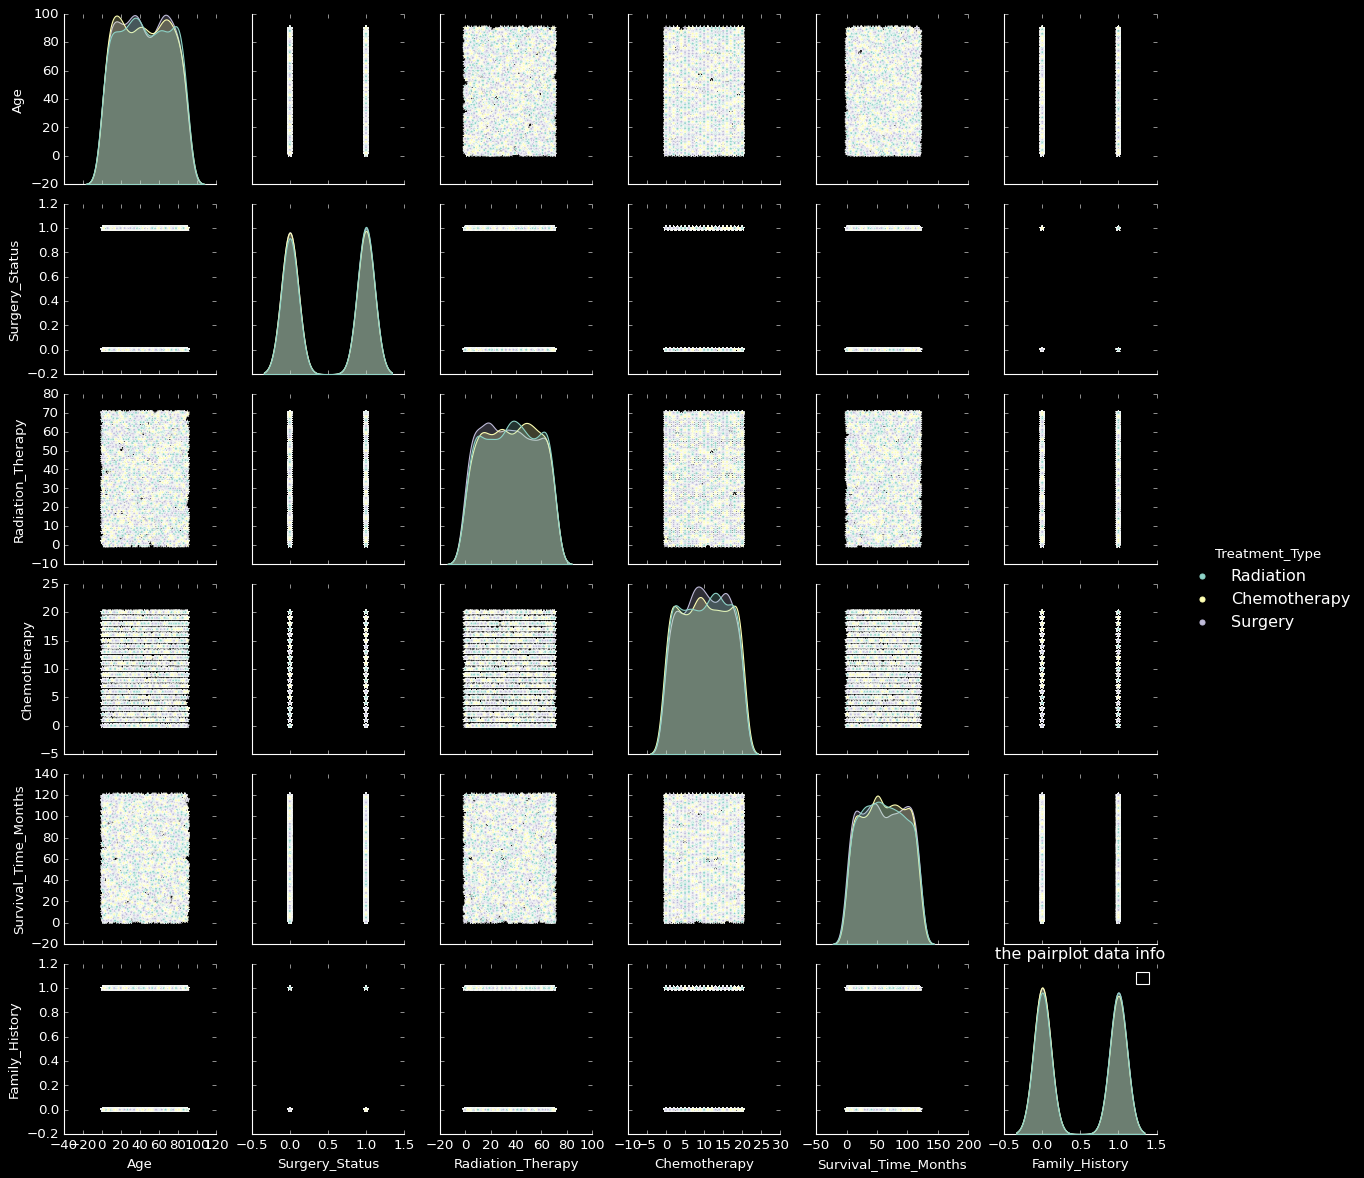

In [22]:
plt.figure(figsize=(10,10))
plt.style.use('dark_background')
sns.pairplot(data=df,markers='*',hue='Treatment_Type')
plt.title('the pairplot data info')
plt.legend()
plt.grid(True)
plt.show()

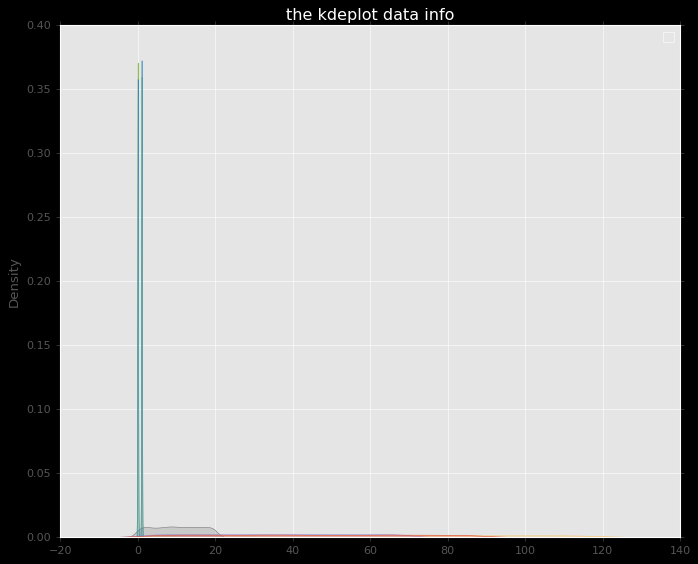

In [23]:
plt.figure(figsize=(10,8))
plt.style.use('ggplot')
sns.kdeplot(data=df,fill=True)
plt.title('the kdeplot data info')
plt.legend()
plt.grid(True)
plt.show()